In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

In [2]:
df=pd.read_csv('loan_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
x=df.drop(columns='loan_status')
y=df['loan_status']

In [6]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
x_train[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

<Axes: >

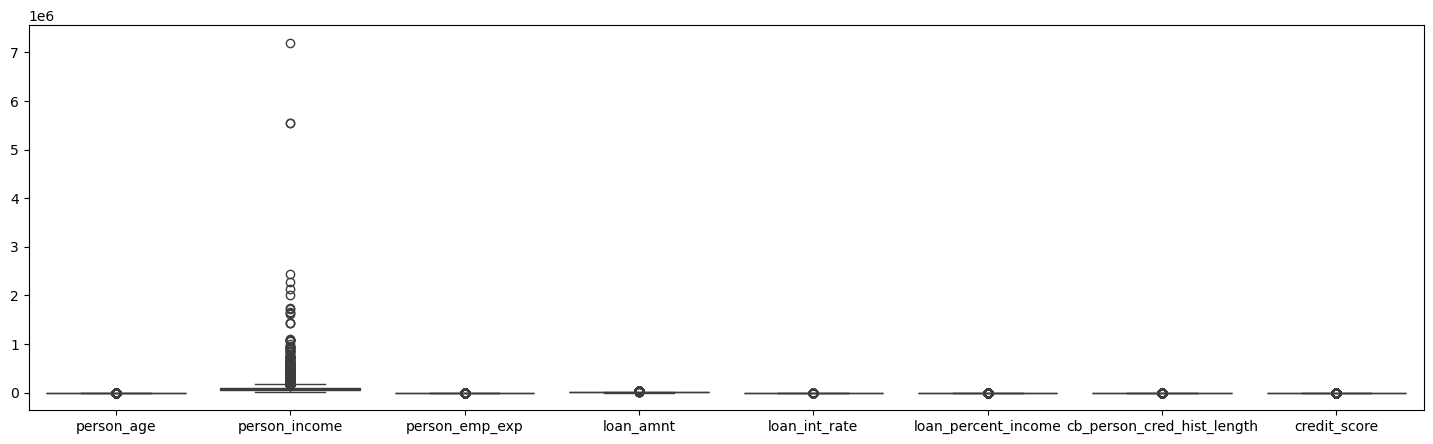

In [10]:
plt.figure(figsize=(18,5))
sns.boxplot(x_train[num_cols])

In [11]:
pre_processing=ColumnTransformer(
    transformers=[
        ('scaler',RobustScaler(),['person_income']),
        ('Standard_scaler',StandardScaler(),['person_age','person_emp_exp','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','credit_score']),
        ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),obj_cols)
    ],
    remainder='passthrough'
)

In [12]:
main_pipeline=Pipeline(
    steps=[
        ('pre_processing',pre_processing),
        ('model',KNeighborsClassifier(n_neighbors=5,metric='euclidean'))
    ]
)

In [13]:
main_pipeline.fit(x_train,y_train)

,steps,"[('pre_processing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('Standard_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
pred_ytrain=main_pipeline.predict(x_train)

In [15]:
print(classification_report(y_train,pred_ytrain))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     28010
           1       0.87      0.79      0.83      7990

    accuracy                           0.93     36000
   macro avg       0.91      0.88      0.89     36000
weighted avg       0.93      0.93      0.93     36000



In [16]:
pred_ytest=main_pipeline.predict(x_test)

In [17]:
print(classification_report(y_test,pred_ytest))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6990
           1       0.80      0.71      0.75      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.90      0.89      9000

